<a href="https://colab.research.google.com/github/shindevaish/InceptionV3_based_Image_Captioning/blob/master/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Name : Vaishnavi Shinde
### Roll no : 58
### Batch : C4
### DL Practical 9

### AIM: Implement CNN-LSTM Architecture Using Inception V3 Model to perform automatic image captioning

### 1. Essential Imports

In [ ]:
import matplotlib.pyplot as plt
import random
import os
import zipfile
import requests
from tqdm.notebook import tqdm
import numpy as np
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
import string
import pickle

### 2. Define Dataset Paths and Download/Extract Flickr8k Dataset

In [ ]:
DATASET_DIR = './flickr8k'

IMAGES_DIR = os.path.join(DATASET_DIR, 'Images', 'Flicker8k_Dataset')
CAPTIONS_PATH = os.path.join(DATASET_DIR, 'Flickr8k.token.txt')


os.makedirs(DATASET_DIR, exist_ok=True)

image_zip_url = 'https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip'
image_zip_path = os.path.join(DATASET_DIR, 'Flickr8k_Dataset.zip')

print(f'Downloading Flickr8k images from {image_zip_url}...')
response = requests.get(image_zip_url, stream=True)
response.raise_for_status()
with open(image_zip_path, 'wb') as f:
    total_size = int(response.headers.get('content-length', 0))
    for chunk in tqdm(response.iter_content(chunk_size=1024), total=total_size // 1024, unit='KB'):
        f.write(chunk)

print('Extracting images...')
with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:

    zip_ref.extractall(os.path.join(DATASET_DIR, 'Images'))


caption_zip_url = 'https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip'
caption_zip_path = os.path.join(DATASET_DIR, 'Flickr8k_text.zip')

print(f'Downloading Flickr8k captions from {caption_zip_url}...')
response = requests.get(caption_zip_url, stream=True)
response.raise_for_status()
with open(caption_zip_path, 'wb') as f:
    total_size = int(response.headers.get('content-length', 0))
    for chunk in tqdm(response.iter_content(chunk_size=1024), total=total_size // 1024, unit='KB'):
        f.write(chunk)

print('Extracting captions...')
with zipfile.ZipFile(caption_zip_path, 'r') as zip_ref:

    zip_ref.extractall(DATASET_DIR)

print('Dataset download and extraction complete.')
print(f'Images are in: {IMAGES_DIR}')
print(f'Captions file is in: {CAPTIONS_PATH}')

  0%|          | 0/1089277 [00:00<?, ?KB/s]

Extracting images...


  0%|          | 0/2285 [00:00<?, ?KB/s]

Extracting captions...
Dataset download and extraction complete.
Images are in: ./flickr8k/Images/Flicker8k_Dataset
Captions file is in: ./flickr8k/Flickr8k.token.txt


### 3. Verify Dataset Contents (Diagnostic)

In [ ]:
print(f"Contents of {IMAGES_DIR}:")
for item in os.listdir(IMAGES_DIR):
    print(f"- {item}")

print(f"\nFirst 10 lines of {CAPTIONS_PATH}:")
with open(CAPTIONS_PATH, 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())

Contents of ./flickr8k/Images/Flicker8k_Dataset:
- 2998945968_86f236d1e8.jpg
- 3295391572_cbfde03a10.jpg
- 400851260_5911898657.jpg
- 3480052428_c034b98a08.jpg
- 1321723162_9d4c78b8af.jpg
- 414568315_5adcfc23c0.jpg
- 457875937_982588d918.jpg
- 293327462_20dee0de56.jpg
- 3443703471_14845d8850.jpg
- 3174196837_800689a2f3.jpg
- 2923891109_ea0cc932ed.jpg
- 1370773415_967b1ffde1.jpg
- 3184112120_6ddcd98016.jpg
- 3430526230_234b3550f6.jpg
- 2069279767_fb32bfb2de.jpg
- 3155451946_c0862c70cb.jpg
- 1579798212_d30844b4c5.jpg
- 2926595608_69b22be8d4.jpg
- 2647394564_4843800cff.jpg
- 3199460792_deef518c01.jpg
- 3102363657_dc95fe6850.jpg
- 2762702644_2aa3bf9680.jpg
- 3072172967_630e9c69d0.jpg
- 2817230861_d27341dec0.jpg
- 3494345896_dd6b32cfa3.jpg
- 3429351964_531de1bf16.jpg
- 2279980395_989d48ae72.jpg
- 189740668_0b045f1ff2.jpg
- 1785138090_76a56aaabc.jpg
- 2633201394_ee4a7666ed.jpg
- 340425915_490293058f.jpg
- 2105756457_a100d8434e.jpg
- 2942133798_e57c862a90.jpg
- 2689491604_d8760f57b4.jpg
- 342

### 4. Function to Display Random Image with Captions

In [ ]:
def display_random_image_with_captions(image_folder, caption_file):
    all_files_in_folder = os.listdir(image_folder)
    image_files = [f for f in all_files_in_folder if f.lower().endswith('.jpg') and os.path.isfile(os.path.join(image_folder, f))]

    if not image_files:
        print(f"No .jpg image files found in {image_folder}.")
        return

    random_image_name = random.choice(image_files)
    image_path = os.path.join(image_folder, random_image_name)

    with open(caption_file, 'r') as f:
        captions_raw = f.read().splitlines()

    image_captions = []
    for line in captions_raw:
        if line.startswith(random_image_name):
            parts = line.split('\t')
            if len(parts) > 1:
                image_captions.append(parts[1])

    plt.figure(figsize=(10, 6))
    img = plt.imread(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Image: {random_image_name}')

    print(f'Captions for {random_image_name}:')
    if not image_captions:
        print("  No captions found for this image.")
    else:
        for i, caption in enumerate(image_captions):
            print(f'  {i+1}. {caption}')

    plt.show()

### 5. Caption Loading and Cleaning Functions

In [ ]:
def load_descriptions(filename):
    file = open(filename, 'r')
    text = file.read()
    file.close()
    descriptions = dict()
    for line in text.split('\n'):
        if not line:
            continue
        parts = line.split('\t')
        if len(parts) < 2:
            continue
        image_id, image_desc = parts[0], parts[1]
        image_id = image_id.split('.')[0]
        if image_id not in descriptions:
            descriptions[image_id] = list()
        descriptions[image_id].append(image_desc)
    return descriptions

def clean_descriptions(descriptions):
    table = str.maketrans('', '', string.punctuation)
    for key, desc_list in descriptions.items():
        for i in range(len(desc_list)):
            desc = desc_list[i]
            desc = desc.split()
            desc = [word.lower() for word in desc]
            desc = [word.translate(table) for word in desc]
            desc = [word for word in desc if word.isalpha()]
            desc_list[i] =  ' '.join(desc)

def to_vocabulary(descriptions):
    all_desc = set()
    for key in descriptions.keys():
        for desc in descriptions[key]:
            for word in desc.split():
                all_desc.add(word)
    return all_desc

def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + ' ' + desc)
    data = '\n'.join(lines)
    file = open(filename, 'w')
    file.write(data)
    file.close()

### 6. Load, Clean, and Save Captions

In [ ]:
all_descriptions = load_descriptions(CAPTIONS_PATH)
print(f'Loaded descriptions: {len(all_descriptions)}')

clean_descriptions(all_descriptions)

vocabulary = to_vocabulary(all_descriptions)
print(f'Vocabulary Size: {len(vocabulary)}')

CLEAN_CAPTIONS_PATH = os.path.join(DATASET_DIR, 'clean_captions.txt')
save_descriptions(all_descriptions, CLEAN_CAPTIONS_PATH)
print(f'Cleaned captions saved to: {CLEAN_CAPTIONS_PATH}')

Loaded descriptions: 8092
Vocabulary Size: 8775
Cleaned captions saved to: ./flickr8k/clean_captions.txt


### 7. InceptionV3 Model and Preprocessing Functions


In [ ]:

print("Loading InceptionV3 model...")
model_inception = InceptionV3(weights='imagenet')
model_inception = Model(inputs=model_inception.inputs, outputs=model_inception.layers[-2].output)
print("InceptionV3 model loaded successfully.")


def preprocess_image(image_path):

    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)
    return img

def extract_features(directory, image_id, model):
    image_path = os.path.join(directory, image_id + '.jpg')
    img = preprocess_image(image_path)
    feature = model.predict(img, verbose=0)
    return feature

print("Functions for InceptionV3 feature extraction defined.")

Loading InceptionV3 model...
96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
InceptionV3 model loaded successfully.
Functions for InceptionV3 feature extraction defined.


### 8. Display a Random Image

Captions for 3631023049_8a85bab19f.jpg:
  1. The children are on a tire swing .
  2. Three children play in a large bowl shaped swing .
  3. Three children ride on a round swing while another watches from the grass .
  4. Three children riding on a large swing .
  5. Three smiling children swing in a tire swing at a playground .


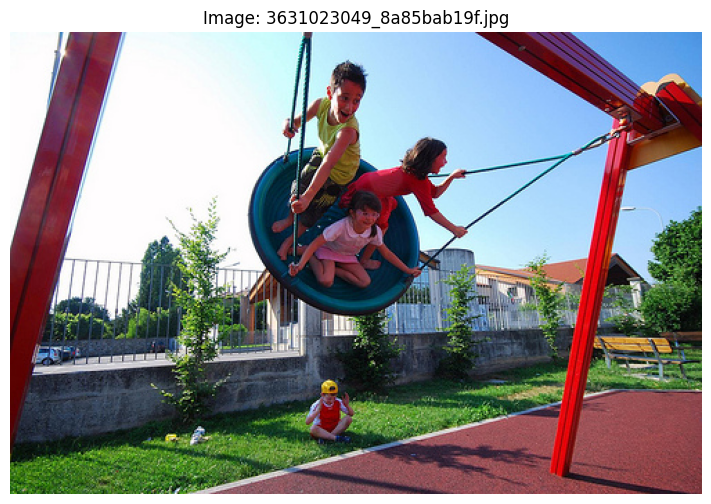

In [ ]:
display_random_image_with_captions(IMAGES_DIR, CAPTIONS_PATH)